# MONAI UNet Training Test Notebook

This notebook provides an interactive way to test and debug the MONAI UNet training pipeline.

## Overview
1. Import libraries
2. Create augmented patches
3. Train the model
4. Generate predictions
5. Visualize results

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

from napari_ai_lab.Augmenters import AlbumentationsAugmenter
from napari_ai_lab.models import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.MonaiUNetSegmenter import (
    MonaiUNetSegmenter,
)

# Global counter for updater
_updater_counter = 0

def simple_updater(message, progress=None):
    global _updater_counter
    _updater_counter += 1

    if _updater_counter % 20 == 0:  # Update every 20 calls
        if progress is not None:
            print(f"📊 Progress: {progress}% - {message}")
        else:
            print(f"📊 {message}")

print("✅ Libraries imported successfully")

/home/bnorthan/code/i2k/tnia/napari-ai-lab/pixi/microsam_cellposesam_czi/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully


In [2]:
import napari

viewer = napari.Viewer()


## 2. Setup Project and Create Augmented Patches

In [3]:
# Setup paths
project_path = Path("/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/")
image_data_model = ImageDataModel(parent_directory=project_path)
patches_dir = image_data_model.get_patches_directory(axis="yx")

print(f"Project path: {project_path}")
print(f"Patches directory: {patches_dir}")

Project path: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project
Patches directory: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/patches/patches_axis_yx


In [4]:
from napari_ai_lab.apps.nd_easy_segment import NDEasySegment

# Add the NDEasySegment widget to the viewer
nd_easy_segment_widget = NDEasySegment(viewer, image_data_model)
viewer.window.add_dock_widget(nd_easy_segment_widget)
nd_easy_segment_widget.automatic_mode_btn.setChecked(True)




Connected to viewer close event
Mode changed to: Automatic
Mode changed to: Automatic


In [5]:
# Load image and annotations
image = image_data_model.load_image(0)
image_data_model.set_prediction_io_type("zarr", axis_slice="YX")

annotations = image_data_model.load_existing_annotations(
    image_shape=image.shape,
    image_index=0,
    subdirectory="class_0",
)

image_layer = viewer.add_image(image, name='Image')
nd_easy_segment_widget._set_image_layer(image_layer)

print(f"Image shape: {image.shape}")
print(f"Annotations shape: {annotations.shape}")
print(f"Image value range: [{image.min()}, {image.max()}]")
print(f"Annotations unique values: {np.unique(annotations)}")

Loading image: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/Test lightsheet.tif
Loaded image shape: (7, 867, 1352)
Axis types: ZYX
Successfully set up layers for image: Image
Image shape: (7, 867, 1352)
Annotations shape: (7, 867, 1352)
Image value range: [172, 5088]
Annotations unique values: [0 1 2 3]
Successfully set up layers for image: Image
Image shape: (7, 867, 1352)
Annotations shape: (7, 867, 1352)
Image value range: [172, 5088]
Annotations unique values: [0 1 2 3]


In [6]:
image_data_model.delete_patches(axis="yx")

In [7]:
# Create augmenter with global normalization and albumentations
num_patches = 200
augmenter = AlbumentationsAugmenter(
    seed=42,
    normalize=True,
    use_global_stats=True,
    do_vertical_flip=True,
    do_horizontal_flip=True,
    do_random_rotate90=True,
    do_random_sized_crop=True,
    do_random_brightness_contrast=True,
    size_factor=0.8
)

axes = "YX"

# Determine patch size
if len(image.shape) == 3:
    patch_size_yx = (1, 128, 128)
    print(f"Generating 2D patches of size {patch_size_yx} (from 3D)...")
elif len(image.shape) == 2:
    patch_size_yx = (128, 128)
    print(f"Generating 2D patches of size {patch_size_yx}...")

# Configure augmentation in image_data_model
image_data_model.set_augmenter(augmenter)
image_data_model.set_patch_size(patch_size_yx)
image_data_model.set_num_patches(num_patches)

# Setup augmentation (computes global stats and valid coordinates)
print("\nSetting up augmentation...")
image_data_model.setup_augmentation(
    image=image,
    annotations=annotations,
    mode="valid_coordinates",
    compute_global_stats=True,
    percentile_low=1,
    percentile_high=99
)

Generating 2D patches of size (1, 128, 128) (from 3D)...

Setting up augmentation...
Computing global normalization statistics from full image...
Computed global normalization stats: low=210.0000, high=1378.0000
Computing valid coordinates for patches...
num coords: 170868
Found 452829 valid positions
Found 452829 valid positions


In [8]:
# Generate patches using ImageDataModel API
patches_dir = image_data_model.generate_patches(
    image=image,
    annotations=annotations,
    axis="yx",
    patch_base_name="yx_patch",
    axes_string=axes,
    num_inputs=1,
    num_truths=1,
    sub_sample=1
)

print(f"\n✅ Patches ready for training in: {patches_dir}")


Generating 200 patches...
  Created 10/200 patches
  Created 20/200 patches
  Created 30/200 patches
  Created 40/200 patches
  Created 50/200 patches
  Created 60/200 patches
  Created 70/200 patches
  Created 80/200 patches
  Created 90/200 patches
  Created 100/200 patches
  Created 110/200 patches
  Created 120/200 patches
  Created 130/200 patches
  Created 140/200 patches
  Created 150/200 patches
  Created 160/200 patches
  Created 170/200 patches
  Created 180/200 patches
  Created 190/200 patches
  Created 200/200 patches

Writing info.json...
✓ Created info.json at /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/patches/patches_axis_yx/info.json
✅ Created 200 patches in /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/patches/patches_axis_yx

✅ Patches ready for training in: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/patches/patches_axis_yx
  Created 130/200 patches
  Created 140/200 p

### About the ImageDataModel Augmentation API

The cells above use the **ImageDataModel augmentation API** which provides a clean, reusable interface:

**Three-step process**:
1. **Configuration**: `set_augmenter()`, `set_patch_size()`, `set_num_patches()`
2. **Setup**: `setup_augmentation()` - computes global stats and valid coordinates
3. **Generation**: `generate_patches()` - creates patches and writes info.json

**Augmentation Modes**:
- `"valid_coordinates"`: Only crop patches containing annotations (✅ used above)
- `"random_crop"`: Randomly crop patches anywhere in the image
- `"marked_roi"`: Crop from user-defined regions (⏳ planned)

## 3. Train the Model

In [15]:
# Create segmenter
segmenter = MonaiUNetSegmenter()

# Set training parameters
segmenter.num_epochs = 700
segmenter.learning_rate = 0.0001
segmenter.weight_c1 = 1  # Background weight
segmenter.weight_c2 = 5  # Foreground weight (higher for rare class)
segmenter.weight_c3 = 5

# Set simple updater for progress output
segmenter.updater = simple_updater

# Set paths
segmenter.patch_path = str(patches_dir)
models_dir = image_data_model.get_models_directory()
segmenter.model_path = str(models_dir)
segmenter.model_name = "monai_unet_test.pth"

print(f"Patch path: {segmenter.patch_path}")
print(f"Model path: {segmenter.model_path}")
print(f"Training for {segmenter.num_epochs} epochs")
print(f"Learning rate: {segmenter.learning_rate}")
print(f"Class weights: [bg={segmenter.weight_c1}, fg={segmenter.weight_c2}]")

Patch path: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/patches/patches_axis_yx
Model path: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/vessels_project/models
Training for 700 epochs
Learning rate: 0.0001
Class weights: [bg=1, fg=5]


In [16]:
# Run training
print("\n🚀 Starting training...\n")
result = segmenter.train()

print("\n✅ Training complete!")
print(f"CUDA available: {result.get('cuda_present')}")
print(f"Device: {result.get('device')}")
print(f"Number of input channels: {result.get('num_inputs')}")
print(f"Number of truth classes: {result.get('num_truths')}")


🚀 Starting training...

🚀 Starting MONAI UNet training...
   Sparse: True
   Num Classes: 2
   Depth: 5
   Features Level 1: 32
   Class Weights: [1, 5, 5]
   Epochs: 700
   Learning Rate: 0.0001
   Dropout: 0.2
   Save Interval: 10
sub_sample 1
axes YX
num_inputs 1
num_truths 1


100%|██████████| 200/200 [00:00<00:00, 2507.18it/s]

Training data size: 200
No validation data found - training without validation

🔍 Training diagnostics:
   Model expects: in_channels=1, out_channels=3
   Data shape from dataset: (200, 1, 128, 128)
   Target shape: (128, 128), Axes: YX


📊 Progress: 2% - Epoch 19 - training loss: 0.5338
📊 Progress: 5% - Epoch 39 - training loss: 0.2284
📊 Progress: 5% - Epoch 39 - training loss: 0.2284
📊 Progress: 8% - Epoch 59 - training loss: 0.1160
📊 Progress: 8% - Epoch 59 - training loss: 0.1160
📊 Progress: 11% - Epoch 79 - training loss: 0.0784
📊 Progress: 11% - Epoch 79 - training loss: 0.0784
📊 Progress: 14% - Epoch 99 - training loss: 0.0654
📊 Progress: 14% - Epoch 99 - training loss: 0.0654
📊 Progress: 17% - Epoch 119 - training loss: 0.0543
📊 Progress: 17% - Epoch 119 - training loss: 0.0543
📊 Progress: 19% - Epoch 139 - training loss: 0.0483
📊 Progress: 19% - Epoch 139 - training loss: 0.0483
📊 Progress: 22% - Epoch 159 - training loss: 0.0481
📊 Progress: 22% - Epoch 159 - training loss: 0.0481
📊 Progress: 25% - Epoch 179 - training loss: 0.0401
📊 Progress: 25% - Epoch 179 - training loss: 0.0401
📊 Progress: 28% - Epoch 199 - training loss: 0.0384
📊 Progress: 28% - Epoch 199 - training loss: 0.0384
📊 Progress: 31% - Epoch 21

## 4. Visualize Training History

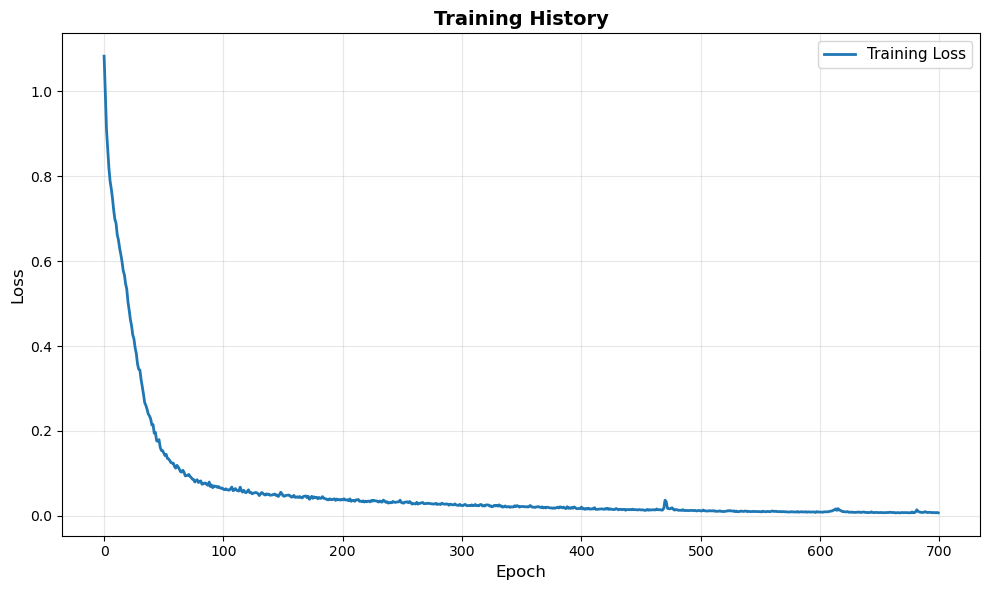

Final training loss: 0.0069


In [17]:
# Plot training and validation loss
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

if len(segmenter.train_loss_list) > 0:
    ax.plot(segmenter.train_loss_list, label='Training Loss', linewidth=2)

if len(segmenter.validation_loss_list) > 0:
    ax.plot(segmenter.validation_loss_list, label='Validation Loss', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training loss: {segmenter.train_loss_list[-1]:.4f}")
if len(segmenter.validation_loss_list) > 0:
    print(f"Final validation loss: {segmenter.validation_loss_list[-1]:.4f}")

## 5. Generate Predictions and Visualize Results

Generate predictions for 5 sample patches and visualize them alongside ground truth.

In [18]:
import torch

from napari_ai_lab.utilities.dl_util import normalize_image


def simple_predict_logits(model, patch, device='cpu', normalize=False):
    """Simple prediction function that returns logits for each class.
    
    Args:
        model: The trained model
        patch: Input patch (already normalized if from training patches)
        device: Device to run inference on ('cpu' or 'cuda')
        normalize: Whether to normalize the patch (default False, patches are already normalized)
    """
    # Optionally normalize the patch
    if normalize:
        patch_normalized = normalize_image(patch, p_low=0.0, p_high=1.0)
    else:
        patch_normalized = patch

    # Add batch and channel dimensions: [H, W] -> [1, 1, H, W]
    if len(patch_normalized.shape) == 2:
        patch_tensor = torch.from_numpy(patch_normalized).unsqueeze(0).unsqueeze(0).float()
    elif len(patch_normalized.shape) == 3 and patch_normalized.shape[0] == 1:
        patch_tensor = torch.from_numpy(patch_normalized).unsqueeze(0).float()
    else:
        patch_tensor = torch.from_numpy(patch_normalized).float()

    # Move to device
    patch_tensor = patch_tensor.to(device)
    model = model.to(device)
    model.eval()

    # Predict
    with torch.no_grad():
        output = model(patch_tensor)  # [1, num_classes, H, W]

        # Get logits for each class
        logits = output.squeeze(0).cpu().numpy()  # [num_classes, H, W]

    probabilities = torch.softmax(output, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1).cpu().numpy().squeeze() + 1

    return logits, predicted_classes


# Get file lists
X = result.get('X')
Y = result.get('Y')

# Check if model is available
if segmenter.model is not None:
    print("✅ Model is loaded and ready")
    print(f"Model type: {type(segmenter.model)}")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    print(f"Number of classes: {segmenter.num_classes}")
else:
    print("⚠️ Model is not loaded!")

print(f"\nTotal training patches: {len(X)}")
print("Visualizing 5 sample predictions...\n")

✅ Model is loaded and ready
Model type: <class 'monai.networks.nets.unet.UNet'>
Using device: cuda
Number of classes: 3

Total training patches: 200
Visualizing 5 sample predictions...



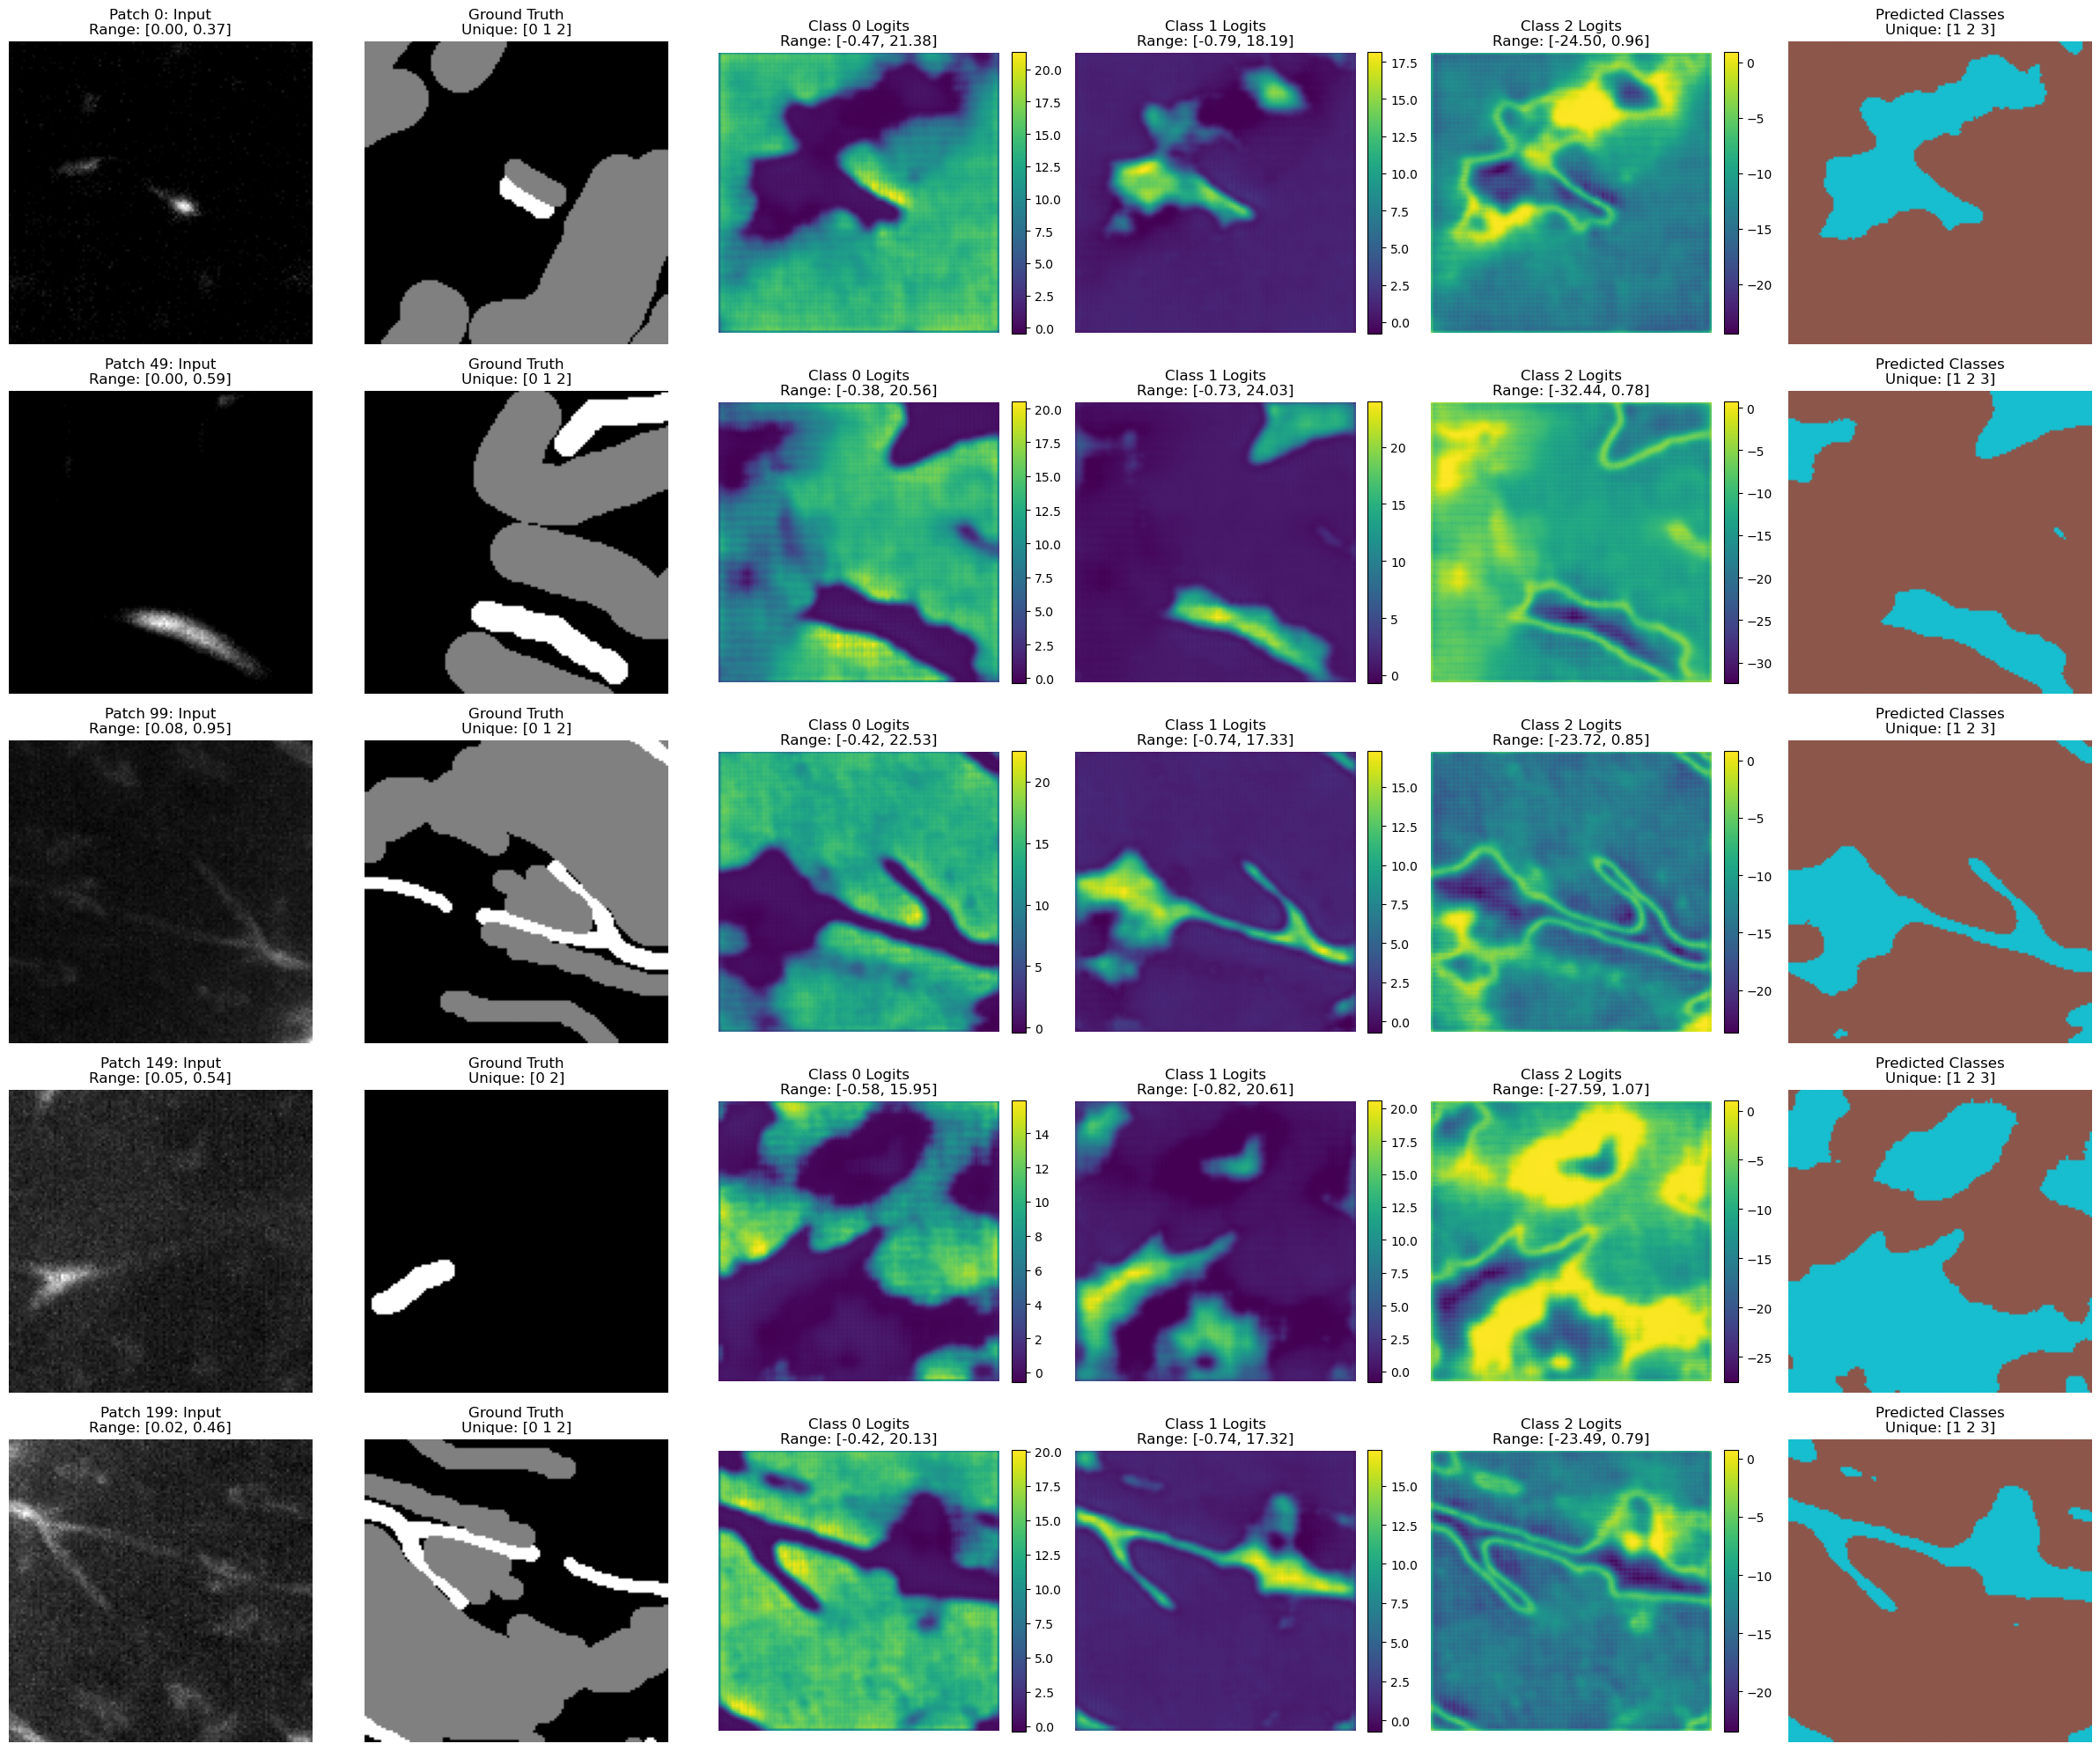

✅ Visualization complete!


In [19]:
# Predict and visualize 5 patches with class logits
num_samples = min(5, len(X))
sample_indices = np.linspace(0, len(X)-1, num_samples, dtype=int)

# Get number of classes from the model
num_classes = segmenter.num_classes

# Create figure: Input | Ground Truth | Class 0 logits | Class 1 logits | Class 2 logits | ...
num_cols = 2 + num_classes + 1  # Input + Truth + one column per class + Predicted Classes
fig, axes = plt.subplots(num_samples, num_cols, figsize=(4*num_cols, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    # Load patch and ground truth
    patch_path = Path(X[idx])
    truth_path = Path(Y[0][idx])

    patch = tifffile.imread(patch_path)
    truth = tifffile.imread(truth_path)

    # Get logits for each class
    logits, predicted_classes = simple_predict_logits(segmenter.model, patch, device=device)


    col = 0

    # Display input
    axes[row, col].imshow(patch, cmap='gray')
    axes[row, col].set_title(f'Patch {idx}: Input\nRange: [{patch.min():.2f}, {patch.max():.2f}]')
    axes[row, col].axis('off')
    col += 1

    # Display ground truth
    axes[row, col].imshow(truth, cmap='gray')
    axes[row, col].set_title(f'Ground Truth\nUnique: {np.unique(truth)}')
    axes[row, col].axis('off')
    col += 1

    # Display logits for each class
    for class_idx in range(num_classes):
        class_logits = logits[class_idx]
        im = axes[row, col].imshow(class_logits, cmap='viridis')
        axes[row, col].set_title(f'Class {class_idx} Logits\nRange: [{class_logits.min():.2f}, {class_logits.max():.2f}]')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
        col += 1

    # Display predicted classes
    axes[row, col].imshow(predicted_classes, cmap='tab10', vmin=0, vmax=num_classes-1)
    axes[row, col].set_title(f'Predicted Classes\nUnique: {np.unique(predicted_classes)}')
    axes[row, col].axis('off')


plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

## 6. Histogram Analysis

In [ ]:
# Create histograms for the first patch including class logits
idx = 0
patch_path = Path(X[idx])
truth_path = Path(Y[0][idx])

patch = tifffile.imread(patch_path)
truth = tifffile.imread(truth_path)
logits = simple_predict_logits(segmenter.model, patch, device=device)

# Create subplots: Input | Truth | Class 0 logits | Class 1 logits | ...
num_cols = 2 + num_classes
fig, axes = plt.subplots(1, num_cols, figsize=(5*num_cols, 4))

col = 0

# Input histogram
axes[col].hist(patch.flatten(), bins=50, color='blue', alpha=0.7)
axes[col].set_title(f'Input Histogram\nRange: [{patch.min():.2f}, {patch.max():.2f}]')
axes[col].set_xlabel('Pixel Value')
axes[col].set_ylabel('Frequency')
axes[col].grid(True, alpha=0.3)
col += 1

# Ground truth histogram
axes[col].hist(truth.flatten(), bins=50, color='green', alpha=0.7)
axes[col].set_title(f'Ground Truth Histogram\nRange: [{truth.min():.2f}, {truth.max():.2f}]')
axes[col].set_xlabel('Pixel Value')
axes[col].set_ylabel('Frequency')
axes[col].grid(True, alpha=0.3)
col += 1

# Logits histogram for each class
colors = ['orange', 'purple', 'brown', 'pink', 'cyan']
for class_idx in range(num_classes):
    class_logits = logits[class_idx]
    color = colors[class_idx % len(colors)]
    axes[col].hist(class_logits.flatten(), bins=50, color=color, alpha=0.7)
    axes[col].set_title(f'Class {class_idx} Logits\nRange: [{class_logits.min():.2f}, {class_logits.max():.2f}]')
    axes[col].set_xlabel('Logit Value')
    axes[col].set_ylabel('Frequency')
    axes[col].grid(True, alpha=0.3)
    col += 1

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Statistics:")
print(f"Input - min: {patch.min():.4f}, max: {patch.max():.4f}, mean: {patch.mean():.4f}, std: {patch.std():.4f}")
print(f"Truth - min: {truth.min():.4f}, max: {truth.max():.4f}, mean: {truth.mean():.4f}, std: {truth.std():.4f}")
for class_idx in range(num_classes):
    class_logits = logits[class_idx]
    print(f"Class {class_idx} Logits - min: {class_logits.min():.4f}, max: {class_logits.max():.4f}, mean: {class_logits.mean():.4f}, std: {class_logits.std():.4f}")

## Summary

This notebook allows you to:
- ✅ Create augmented patches with global normalization
- ✅ Train a MONAI UNet model
- ✅ Visualize training progress
- ✅ Generate predictions on test patches
- ✅ Compare predictions with ground truth
- ✅ Analyze value distributions with histograms

**Debugging Tips:**
- Check that input patches are normalized (should be in [0, 1] range)
- Verify ground truth has expected binary values
- Monitor training loss for convergence
- Compare prediction distributions to ground truth
- Adjust class weights if classes are highly imbalanced